In [50]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict.csv
/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv


In [51]:
df = pd.read_csv("/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv")

In [52]:
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73


In [53]:
df.shape

(500, 9)

In [54]:
df.isna().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
x = df.drop(['Serial No.','Chance of Admit '],axis=True)
y=df['Chance of Admit ']

In [57]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=4)

In [58]:
x_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
303,323,107,3,3.5,3.5,8.55,1
202,340,120,5,4.5,4.5,9.91,1
349,313,101,3,2.5,3.0,8.04,0
272,294,95,1,1.5,1.5,7.64,0
192,322,114,5,4.5,4.0,8.94,1
...,...,...,...,...,...,...,...
385,335,117,5,5.0,5.0,9.82,1
197,310,106,2,3.5,2.5,8.33,0
439,312,105,2,1.5,3.0,8.46,0
174,321,111,4,4.0,4.0,8.97,1


In [59]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [60]:
x_train_scaled

array([[0.66      , 0.53571429, 0.5       , ..., 0.625     , 0.56089744,
        1.        ],
       [1.        , 1.        , 1.        , ..., 0.875     , 0.99679487,
        1.        ],
       [0.46      , 0.32142857, 0.5       , ..., 0.5       , 0.3974359 ,
        0.        ],
       ...,
       [0.44      , 0.46428571, 0.25      , ..., 0.5       , 0.53205128,
        0.        ],
       [0.62      , 0.67857143, 0.75      , ..., 0.75      , 0.69551282,
        1.        ],
       [0.4       , 0.5       , 0.75      , ..., 0.375     , 0.5       ,
        0.        ]])

In [61]:
import tensorflow
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [62]:
model= Sequential()

In [63]:
model = Sequential([
    Dense(16,activation="relu",input_shape=(7,)),
    Dense(5,activation='relu'),
    Dense(1,activation="linear")
    
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │            85 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219 (876.00 B)

 Trainable params: 219 (876.00 B)

 Non-trainable params: 0 (0.00 B)

In [88]:
model.compile(loss='mean_squared_error',optimizer="Adam",metrics=['accuracy'])

In [89]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(patience=10,monitor="val_loss",restore_best_weights=True)
history=model.fit(x_train_scaled,y_train,validation_split=0.2,epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.0000e+00 - loss: 0.0032 - val_accuracy: 0.0000e+00 - val_loss: 0.0039
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 0.0032 - val_accuracy: 0.0000e+00 - val_loss: 0.0039
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: 0.0032 - val_accuracy: 0.0000e+00 - val_loss: 0.0040
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 0.0032 - val_accuracy: 0.0000e+00 - val_loss: 0.0039
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 0.0032 - val_accuracy: 0.0000e+00 - val_loss: 0.0038
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 0.0032 - val_accuracy: 0.0000e+00 - val_loss: 0.0039
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 0.0031 - val_accuracy: 0.0000e+00 - val_loss: 0.0040
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/st

In [90]:
y_pred=model.predict(x_test_scaled).ravel()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [91]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.782043763035191

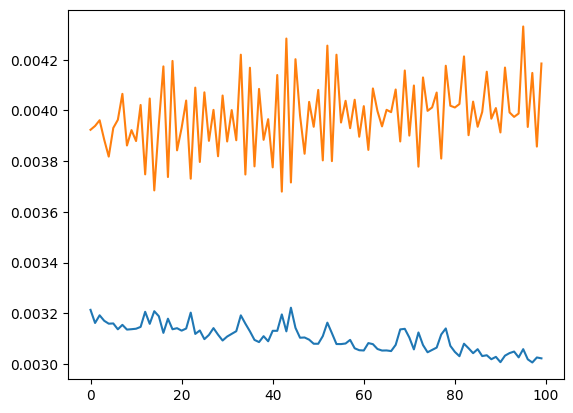

In [92]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

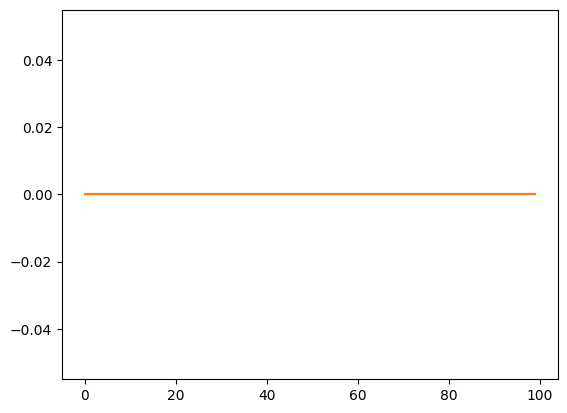

In [93]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])